In [ ]:
%autoreload 2

In [3]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25736\1284024126.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [41]:
path = "C://Data//Imaging//"
all_df = []
paths = [
 #     r"C:\Data\Imaging\260402_overlap\fish3_2",
 # r"C:\Data\Imaging\260402_overlap\fish3",
        #  r"C:\Data\Imaging\260402_overlap\fish4_2",
#r"C:\Data\Imaging\260402_overlap\fish4",
    # r"C:\Data\Imaging\260402_overlap\fish5",
    r"C:\Data\Imaging\260402_overlap\fish5_2",
]
for fish in paths:
    saccade_df = pd.read_csv( fish + '//eye//eye_saccade_df.csv', index_col=0)
    saccade_df.loc[:, "fish_id"] = fish
    all_df.append(saccade_df)
all_df = pd.concat(all_df).reset_index(drop = True)

In [42]:
stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
# stim_matrix = np.array([['dot_l_3', 'dot_r_3'],
#                         ['dot_l_5', 'dot_r_5'],
#                         ['dot_l_10', 'dot_r_10'],
#                         ['dot_l_20', 'dot_r_20'],
#                         ['dot_l_40', 'dot_r_40']])
# stim_matrix = np.array([['dot_l_aaa', 'dot_r_aaa'],
#                         ['dot_l_aab', 'dot_r_aab'],
#                         ['dot_l_aba', 'dot_r_aba'],
#                         ['dot_l_abb', 'dot_r_abb'],
#                        ['dot_l_baa', 'dot_r_baa'],
#                         ['dot_l_bab',  'dot_r_bab'],
#                         ['dot_l_bba', 'dot_r_bba'],
#                         ['dot_l_bbb', 'dot_r_bbb'],
#                        ['dot_l_caa', 'dot_r_caa'],
#                         ['dot_l_cab', 'dot_r_cab'],
#                         ['dot_l_cba', 'dot_r_cba'],
#                         ['dot_l_cbb', 'dot_r_cbb']])
# stim_matrix = np.array([['pause', 'skip'],
#                        ['left', 'right'],
#                        ['dot_l', 'dot_r']])
stimorder = ['stationary', 'forward', 'backward', 'left', 'right', 'dot_l', 'dot_r',
                     str(['dot_l', 'forward']), str(['dot_l', 'backward']), str(['dot_l', 'left']), str(['dot_l', 'right']),
                     str(['dot_r', 'forward']), str(['dot_r', 'backward']), str(['dot_r', 'left']), str(['dot_r', 'right']),]
stimorder = ['stationary', f'dot_l_3', f'dot_r_3', f'dot_l_5',f'dot_r_5', f'dot_l_10', f'dot_r_10', f'dot_l_20',f'dot_r_20', f'dot_l_40', f'dot_r_40']
stimorder = ['dot_l_aaa', 'dot_r_aaa', 'dot_l_aab', 'dot_r_aab', 'dot_l_aba', 'dot_r_aba', 'dot_l_abb', 'dot_r_abb',
              'dot_l_baa', 'dot_r_baa', 'dot_l_bab',  'dot_r_bab', 'dot_l_bba', 'dot_r_bba',  'dot_l_bbb', 'dot_r_bbb',
              'dot_l_caa', 'dot_r_caa','dot_l_cab', 'dot_r_cab', 'dot_l_cba', 'dot_r_cba', 'dot_l_cbb', 'dot_r_cbb']
stimorder = ['stationary', 'left', 'right', 'dot_l', 'dot_r']

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25736\1832532959.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


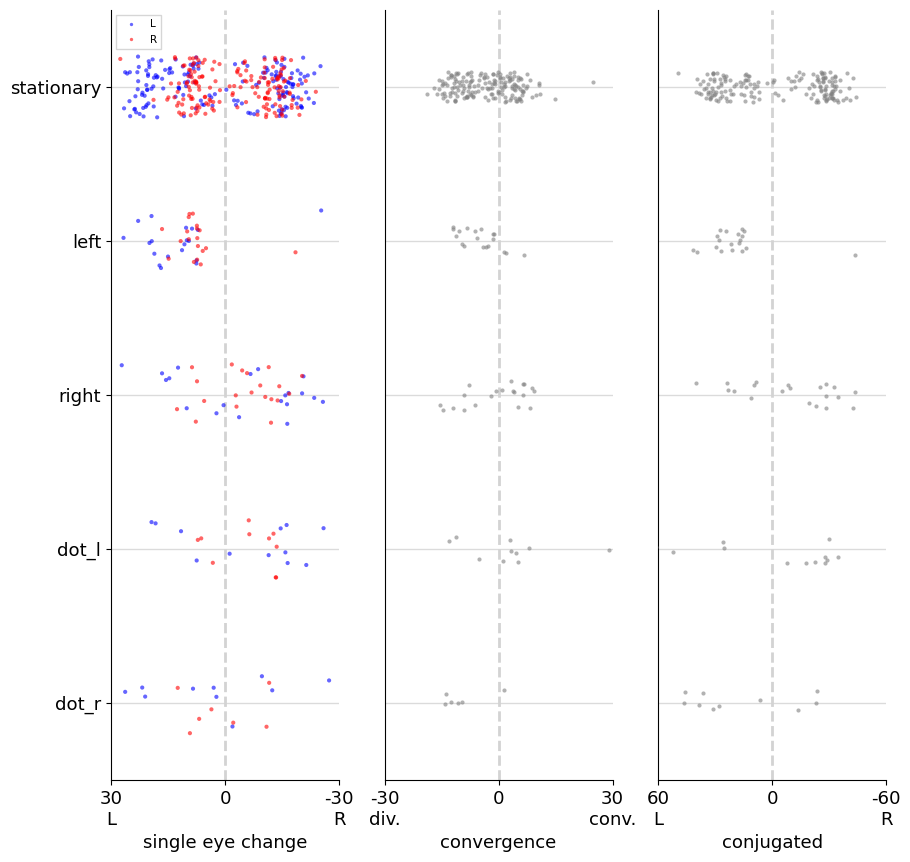

In [31]:
def plot_individual_saccade(all_df, stimorder):
    """
    Plot a scatter plot, with each dot indicating a single saccade
    :param all_df:
    :param stimorder:
    :return:
    """
    fig, ax = plt.subplots(1, 3, figsize = (10, 10))

    temp_all_df = all_df.melt(id_vars = 'eye_realstimuli', value_vars = ['e0_change', 'e1_change'], var_name= 'eye', value_name = 'change')
    sns.stripplot(temp_all_df, y = 'eye_realstimuli', x = 'change', hue = 'eye', hue_order = ['e0_change', 'e1_change'], palette = ['blue', 'red'], ax = ax[0], order = stimorder, legend = True, dodge = False, jitter = .2, orient = 'h', alpha = 0.6, size = 3)
    sns.stripplot(all_df, y = 'eye_realstimuli', x = 'e_conv_change',  color = 'grey', ax = ax[1], order= stimorder,  orient = 'h', size = 3, alpha = 0.6)
    sns.stripplot(all_df, y = 'eye_realstimuli', x = 'e_conj_change',  color = 'grey', ax = ax[2], order= stimorder,  orient = 'h', size = 3, alpha = 0.6)

    for axis in ax:
        axis.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
        axis.grid(False)
        axis.set_ylabel('')
        axis.set_xlim([-30, 30])
        axis.spines[['top', 'right']].set_visible(False)
        for i in range(len(stimorder)):
            axis.axhline(i, linewidth = 1, alpha = 0.8, zorder = -3, color = 'lightgrey')
    ax[0].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].set_yticks([])
    ax[1].set_yticks([])
    ax[0].set_xlabel('single eye change')
    ax[1].set_xlabel('convergence')
    ax[2].set_xlabel('conjugated')
    ax[0].set_yticklabels(stimorder, rotation =0)
    #make sense of the axis
    ax[0].legend(ax[0].get_legend_handles_labels()[0], ['L', 'R'], loc='upper left', fontsize = 'xx-small',
                     markerscale = .8,  fancybox = False)
    ax[0].set_xticks([30, 0, -30])
    ax[0].set_xticklabels(['30\nL', '0', '-30\nR'])
    ax[1].set_xticks([-30, 0, 30])
    ax[1].set_xticklabels(['-30\ndiv.', '0', '30\nconv.'])
    ax[2].set_xticks([60, 0, -60])
    ax[2].set_xticklabels(['60\nL', '0', '-60\nR'])
    return fig

fig = plot_individual_saccade(all_df, stimorder)
plt.show()
plt.close()
#fig.savefig(r"C://Data//Imaging//260325_frmd7//All_behavior//individual_saccade_Casper.png")

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25736\2573884247.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


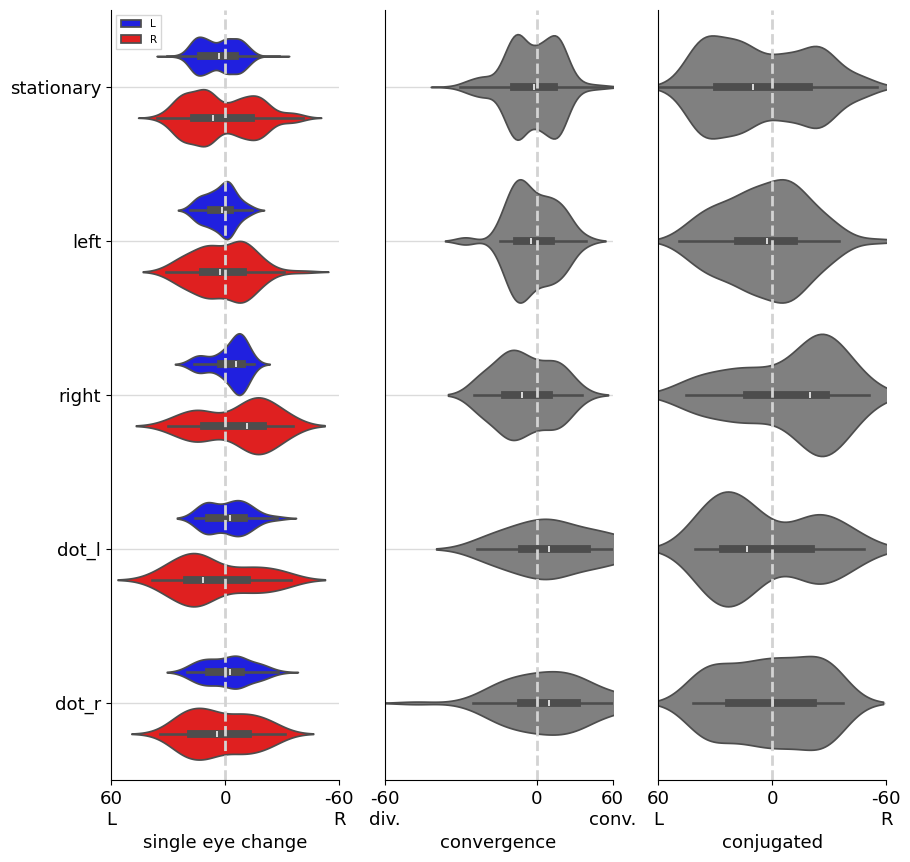

In [23]:
def plot_individual_saccade_stats(all_df, stimorder):
    """
    Plot a violin plot, with each dot indicating a single saccade
    :param all_df:
    :param stimorder:
    :return:
    """
    fig, ax = plt.subplots(1, 3, figsize = (10, 10))
    temp_all_df = all_df.melt(id_vars = 'eye_realstimuli', value_vars = ['e0_change', 'e1_change'], var_name= 'eye', value_name = 'change')
    sns.violinplot(temp_all_df, y = 'eye_realstimuli', x = 'change', hue = 'eye', hue_order = ['e0_change', 'e1_change'], palette = ['blue', 'red'], ax = ax[0], order = stimorder, legend = True, orient = 'h', zorder = 0)
    sns.violinplot(all_df, y = 'eye_realstimuli', x = 'e_conv_change',  color = 'grey', ax = ax[1], order= stimorder,  orient = 'h', zorder = 0)
    sns.violinplot(all_df, y = 'eye_realstimuli', x = 'e_conj_change',  color = 'grey', ax = ax[2], order= stimorder,  orient = 'h', zorder = 0)

    for axis in ax:
        axis.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
        axis.grid(False)
        axis.set_ylabel('')
        axis.set_xlim([-30, 30])
        axis.spines[['top', 'right']].set_visible(False)
        for i in range(len(stimorder)):
            axis.axhline(i, linewidth = 1, alpha = 0.8, zorder = -3, color = 'lightgrey')
    ax[0].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].set_yticks([])
    ax[1].set_yticks([])
    ax[0].set_xlabel('single eye change')
    ax[1].set_xlabel('convergence')
    ax[2].set_xlabel('conjugated')
    ax[0].set_yticklabels(stimorder, rotation =0)
    #make sense of the axis
    ax[0].legend(ax[0].get_legend_handles_labels()[0], ['L', 'R'], loc='upper left', fontsize = 'xx-small',
                     markerscale = .8,  fancybox = False)
    ax[0].set_xticks([60, 0, -60])
    ax[0].set_xticklabels(['60\nL', '0', '-60\nR'])
    ax[1].set_xticks([-60, 0, 30])
    ax[1].set_xticklabels(['-60\ndiv.', '0', '60\nconv.'])
    ax[2].set_xticks([60, 0, -60])
    ax[2].set_xticklabels(['60\nL', '0', '-60\nR'])
    return fig
fig = plot_individual_saccade_stats(all_df, stimorder)
plt.show()
plt.close()
#fig.savefig(r"C://Data//Imaging//260317_dotsweep//All_behavior//individual_saccade_v2.png")

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25736\1162155608.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


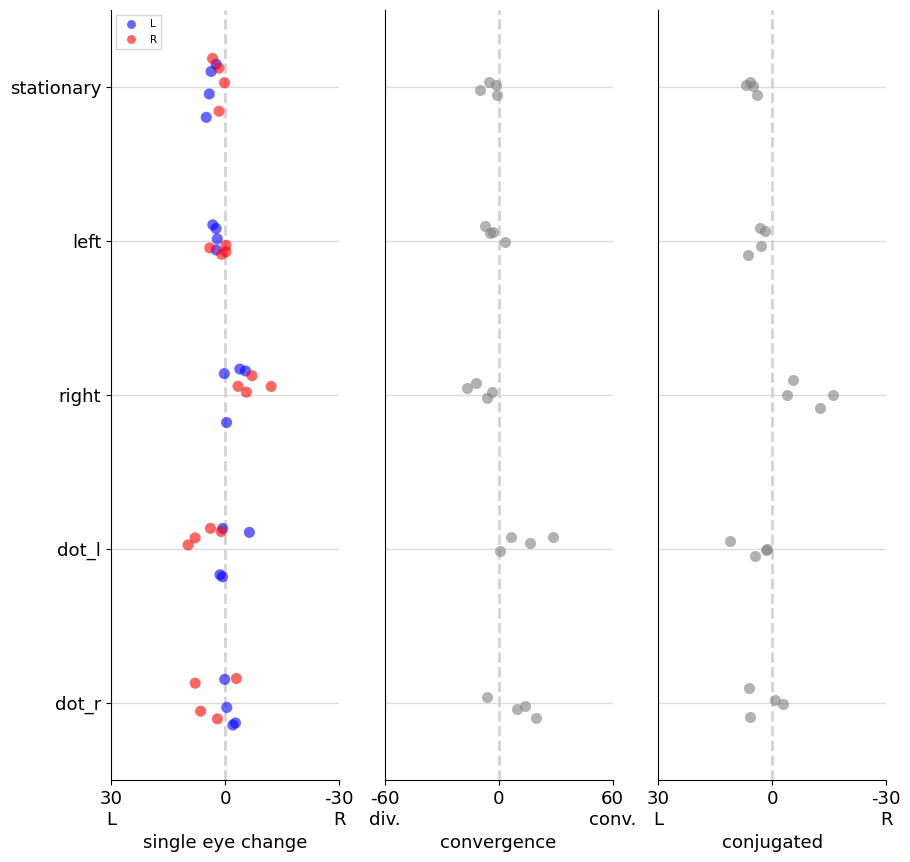

In [24]:
def plot_fish_saccade(all_df, stimorder):
    """Plot mean saccade for individual fish
    """
    all_df = all_df.drop(['cont_tuples_realtime_s', 'cont_tuples_eyeindex', 'eye_stimuli'], axis = 1).groupby(['eye_realstimuli', 'fish_id']).mean().reset_index()
    fig, ax = plt.subplots(1, 3, figsize = (10, 10))
    temp_all_df = all_df.melt(id_vars = 'eye_realstimuli', value_vars = ['e0_change', 'e1_change'], var_name= 'eye', value_name = 'change')
    sns.stripplot(temp_all_df, y = 'eye_realstimuli', x = 'change', hue = 'eye', hue_order = ['e0_change', 'e1_change'], palette = ['blue', 'red'], ax = ax[0], order = stimorder, legend = True, dodge = False, jitter = .2, orient = 'h', alpha = 0.6, size = 8)
    sns.stripplot(all_df, y = 'eye_realstimuli', x = 'e_conv_change',  color = 'grey', ax = ax[1], order= stimorder,  orient = 'h', size = 8, alpha = 0.6)
    sns.stripplot(all_df, y = 'eye_realstimuli', x = 'e_conj_change',  color = 'grey', ax = ax[2], order= stimorder,  orient = 'h', size = 8, alpha = 0.6)

    for axis in ax:
        axis.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
        axis.grid(False)
        axis.set_ylabel('')
        axis.set_xlim([-30, 30])
        axis.spines[['top', 'right']].set_visible(False)
        for i in range(len(stimorder)):
            axis.axhline(i, linewidth = 1, alpha = 0.8, zorder = -3, color = 'lightgrey')
    ax[0].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].set_yticks([])
    ax[1].set_yticks([])
    ax[0].set_xlabel('single eye change')
    ax[1].set_xlabel('convergence')
    ax[2].set_xlabel('conjugated')
    ax[0].set_yticklabels(stimorder, rotation =0)
    #make sense of the axis
    ax[0].legend(ax[0].get_legend_handles_labels()[0], ['L', 'R'], loc='upper left', fontsize = 'xx-small',
                     markerscale = .8,  fancybox = False)
    ax[0].set_xticks([30, 0, -30])
    ax[0].set_xticklabels(['30\nL', '0', '-30\nR'])
    ax[1].set_xticks([-30, 0, 30])
    ax[1].set_xticklabels(['-60\ndiv.', '0', '60\nconv.'])
    ax[2].set_xticks([30, 0, -30])
    ax[2].set_xticklabels(['30\nL', '0', '-30\nR'])
    plt.show()
    plt.close()
    return fig
fig = plot_fish_saccade(all_df, stimorder)
plt.show()
plt.close()
fig.savefig(r"C://Data//Imaging//260325_frmd7//All_behavior//individual_saccade_byfish_Casper.png")

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25736\2178480791.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


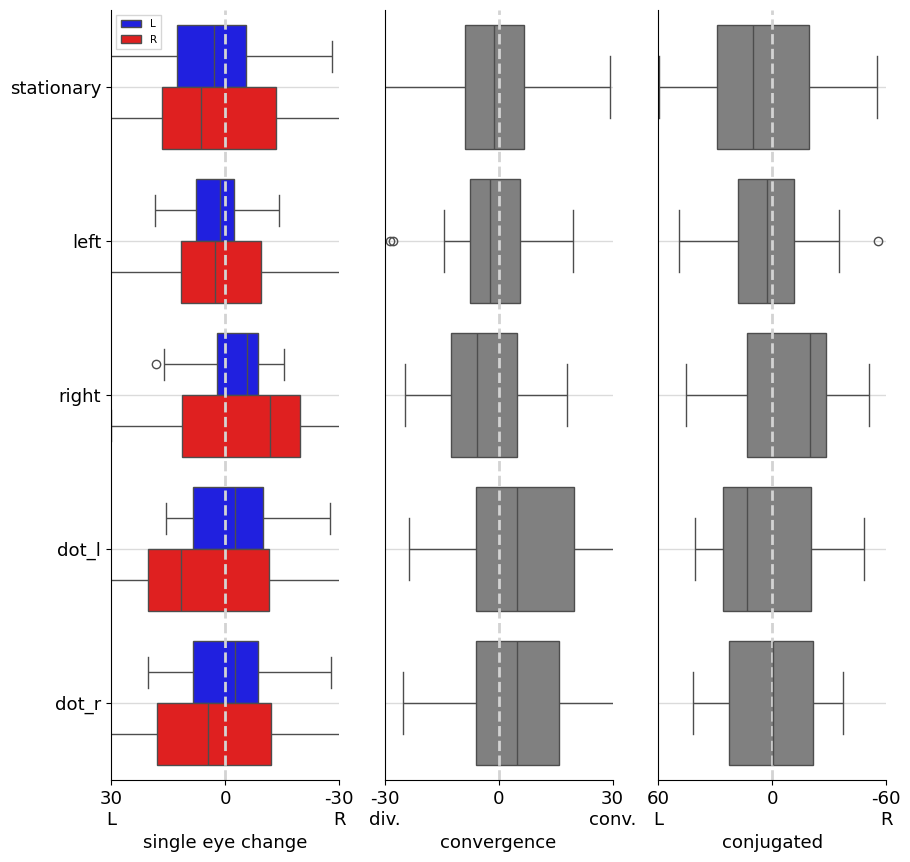

In [25]:
def plot_fish_saccade_stats(all_df, stimorder):
    fig, ax = plt.subplots(1, 3, figsize = (10, 10))
    temp_all_df = all_df.melt(id_vars = 'eye_realstimuli', value_vars = ['e0_change', 'e1_change'], var_name= 'eye', value_name = 'change')
    sns.boxplot(temp_all_df, y = 'eye_realstimuli', x = 'change', hue = 'eye', hue_order = ['e0_change', 'e1_change'], palette = ['blue', 'red'], ax = ax[0], order = stimorder, legend = True, dodge = True, orient = 'h')
    sns.boxplot(all_df, y = 'eye_realstimuli', x = 'e_conv_change',  color = 'grey', ax = ax[1], order= stimorder,  orient = 'h')
    sns.boxplot(all_df, y = 'eye_realstimuli', x = 'e_conj_change',  color = 'grey', ax = ax[2], order= stimorder,  orient = 'h')

    for axis in ax:
        axis.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
        axis.grid(False)
        axis.set_ylabel('')
        axis.set_xlim([-30, 30])
        axis.spines[['top', 'right']].set_visible(False)
        for i in range(len(stimorder)):
            axis.axhline(i, linewidth = 1, alpha = 0.8, zorder = -3, color = 'lightgrey')
    ax[0].invert_xaxis()
    ax[2].invert_xaxis()
    ax[2].set_yticks([])
    ax[1].set_yticks([])
    ax[0].set_xlabel('single eye change')
    ax[1].set_xlabel('convergence')
    ax[2].set_xlabel('conjugated')
    ax[0].set_yticklabels(stimorder, rotation =0)
    #make sense of the axis
    ax[0].legend(ax[0].get_legend_handles_labels()[0], ['L', 'R'], loc='upper left', fontsize = 'xx-small',
                     markerscale = .8,  fancybox = False)
    ax[0].set_xticks([30, 0, -30])
    ax[0].set_xticklabels(['30\nL', '0', '-30\nR'])
    ax[1].set_xticks([-30, 0, 30])
    ax[1].set_xticklabels(['-30\ndiv.', '0', '30\nconv.'])
    ax[2].set_xticks([60, 0, -60])
    ax[2].set_xticklabels(['60\nL', '0', '-60\nR'])
    plt.show()
    plt.close()
    return fig
fig = plot_fish_saccade_stats(all_df, stimorder)
plt.show()
plt.close()
fig.savefig(r"C://Data//Imaging//260325_frmd7//All_behavior//individual_saccade_byfishv2_Casper.png")

skip
dot_l
plotting 2p setup dot position
dot_r
plotting 2p setup dot position
[np.str_('dot_l'), np.str_('dot_r')] [np.str_('skip')]
forward
['dot_l', 'forward']
['dot_r', 'forward']
[np.str_("['dot_l', 'forward']"), np.str_("['dot_r', 'forward']")] [np.str_('forward')]
left
['dot_l', 'left']
['dot_r', 'left']
[np.str_("['dot_l', 'left']"), np.str_("['dot_r', 'left']")] [np.str_('left')]
right
['dot_l', 'right']
['dot_r', 'right']
[np.str_("['dot_l', 'right']"), np.str_("['dot_r', 'right']")] [np.str_('right')]
backward
['dot_l', 'backward']
['dot_r', 'backward']
[np.str_("['dot_l', 'backward']"), np.str_("['dot_r', 'backward']")] [np.str_('backward')]


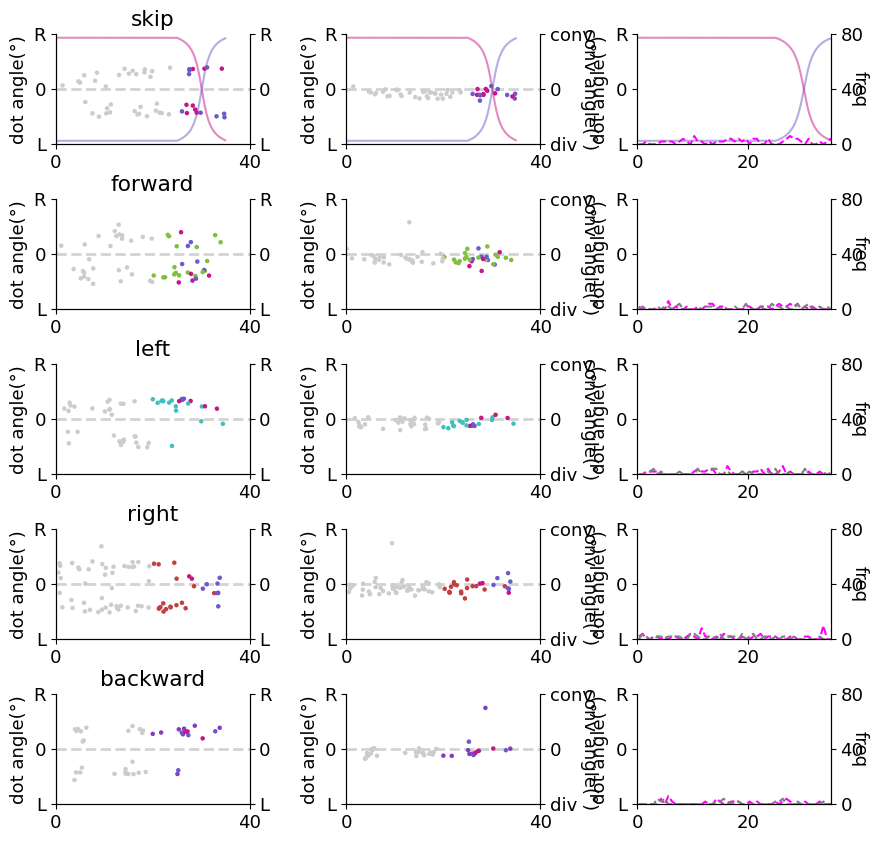

In [43]:
#plot changing eyes across time
stim_path = r"C:\Data\Imaging\260402_overlap\overlap_stim_260402.hdf"
stimulus_df = pd.read_hdf(stim_path, dtype=object).reset_index(drop=True)

# make stimulus file stationary friendly
for n, row in stimulus_df.iterrows():
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][1]:  # actual dot only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][0]
        stimulus_df.loc[n, 'angle'] = row['angle'][0]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][0]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][0]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][0]]
    if type(row['stim_name']) == list and 'stationary' in row['stim_name'][0]:  # actual grating only
        stimulus_df.loc[n, 'stim_name'] = row['stim_name'][1]
        stimulus_df.loc[n, 'angle'] = row['angle'][1]
        stimulus_df.loc[n, 'stationary_time'] = row['stationary_time'][1]
        stimulus_df.loc[n, 'velocity'] = row['velocity'][1]
        stimulus_df.at[n, 'circle_center'] = [row['circle_center'][1]]
stimulus_df.stim_name = [str(i) for i in stimulus_df.stim_name]

def plot_individual_saccade_overtime(all_df, stim_matrix, stims):
    fig, ax = plt.subplots(len(stim_matrix), 3, figsize = (10, 10), gridspec_kw = {'wspace': 0.5, 'hspace': 0.5})
    for n, row in enumerate(stim_matrix):
        for stim in row:
            print(stim)
            if stim =='skip' or stim == 'pause' or '[' in stim:
                continue
            if 'dot_l' in stim:
                stimc = 'slateblue'
            elif 'dot_r' in stim:
                stimc = 'mediumvioletred'
            elif 'left' in stim:
                stimc = 'blue'
            elif 'right' in stim:
                stimc = 'red'
            # elif 'pause' in stim:
            #     stimc = 'grey'
            stim_df = stims[stims['stim_name'] == stim].iloc[0]
            _, stim_loc_timescale, stim_loc_scale, center_time= utils.get_dot_pos(stim_df, canvas_size=1024)
            #because it's behavior rig, stim_loc_scale got changed
            #stim_loc_scale = np.subtract(0, stim_loc_scale)
            [ax[n, col].plot(stim_loc_timescale, stim_loc_scale, c = stimc, alpha = 0.5, zorder = 0) for col in range(3)]
        row_saccade_df = all_df.loc[all_df['eye_stimuli'].isin(row)]
        stim_c = ['grey' if 'pause' in s else 'slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else utils.stim_colors[s] for s in row_saccade_df.eye_realstimuli]#['slateblue' if 'dot_l' in s else 'mediumvioletred' if 'dot_r' in s else 'grey' for s in row_saccade_df.eye_realstimuli]
        ax_conj = ax[n,0].twinx()
        ax_conj.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conj_change, color = stim_c, s = 5, zorder = 2)
        ax_conv = ax[n,1].twinx()
        ax_conv.scatter(row_saccade_df.eye_fromstart_s, row_saccade_df.e_conv_change, color = stim_c, s = 5, zorder = 2)
        ax[n, 0].set_title(f"{row[0].split('_')[-1]}")
        ax[n, 0].set_ylabel('dot angle(°)')
        ax_conj.yaxis.set_label_position("right")
        ax[n, 1].set_ylabel('dot angle(°)')
        ax_conv.yaxis.set_label_position("right")
        ax_conv.set_ylabel('conv angle(°)', rotation = 270)
        #[ax[n, col].axvline(center_time, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1) for col in range(2)]
        [ax[n, col].axhline(0, linewidth = 2, color = 'lightgrey', linestyle = '--', zorder = -1)  for col in range(2)]
        [ax[n, col].set_xlim([0, 40]) for col in range(2)]
        [ax[n, col].set_xticks([0, 40]) for col in range(2)]
        [ax[n, col].set_ylim([-80, 80]) for col in range(2)]
        [ax[n, col].set_yticks([-80,0, 80]) for col in range(2)]
        [ax[n, col].set_yticklabels(['L', 0, 'R']) for col in range(2)]
        ax_conj.set_ylim([-80, 80])
        ax_conj.set_yticks([-80,0, 80])
        ax_conj.set_yticklabels(['L', 0, 'R'])
        ax_conv.set_ylim([-60, 60])
        ax_conv.set_yticks([-60,0, 60])
        ax_conv.set_yticklabels(['div', 0, 'conv'])
        [ax[n, col].spines[['top']].set_visible(False) for col in range(2)]
        ax_conv.spines[['top']].set_visible(False)
        ax_conj.spines[['top']].set_visible(False)

        #plot frequency over time
        ax_freq = ax[n,2].twinx()
        dot_stims = [s for s in row if 'dot' in s]
        nondot_stims = [s for s in row if 'dot' not in s]
        row_saccade_dot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(dot_stims)]
        row_saccade_nondot_df = row_saccade_df[row_saccade_df['eye_stimuli'].isin(nondot_stims)]
        print(dot_stims, nondot_stims)
        if len(row_saccade_dot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_dot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'magenta', linestyle = '--', zorder = 1)
        if len(row_saccade_nondot_df) > 0:
            freq, bin_loc = np.histogram(row_saccade_nondot_df.eye_fromstart_s, bins = 60, range = [0, 40])
            bin_center = (bin_loc[:-1] + bin_loc[1:]) / 2
            ax_freq.plot(bin_center, np.multiply(freq, 2), color = 'grey', linestyle = '--', zorder = 1)
        ax_freq.spines[['top']].set_visible(False)
        ax[n,2].spines[['top']].set_visible(False)
        ax[n, 2].set_xlim([0, 35])
        ax_freq.set_xlim([0, 35])
        ax[n, 2].set_ylim([-80, 80])
        ax[n, 2].set_yticks([-80,0, 80])
        ax[n, 2].set_yticklabels(['L', 0, 'R'])
        ax_freq.set_ylim([0, 80])
        ax_freq.set_yticks([0, 40, 80])
        ax[n, 2].set_ylabel('dot angle(°)')
        ax_freq.set_ylabel('freq', rotation = -90)
    return fig

fig = plot_individual_saccade_overtime(all_df, stim_matrix, stimulus_df)
#fig.savefig(r"C:\Data\Imaging\260325_frmd7\All_behavior//saccade_acrosstime_Casper.svg")
plt.show()
plt.close()

In [28]:
pd.read_hdf(r"C:\Data\Imaging\250912_overlap\overlap_stim_250911.hdf")

,stim_name,angle,velocity,stim_type,stationary_time,duration,texture,circle_center,circle_radius,angular_velocity
0,"[dot_l, left]","[90, 270]","[0.059200955336826844, 0.02]","[m, m]","[24, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
1,"[dot_r, stationary_right]","[-90, 90]","[0.059200955336826844, 0.02]","[m, m]","[24, 30]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, -35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
2,"[dot_l, backward]","[90, 180]","[0.059200955336826844, 0.02]","[m, m]","[24, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
3,"[stationary_dot_l, right]","[90, 90]","[0.059200955336826844, 0.02]","[m, m]","[30, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
4,"[stationary_dot_r, left]","[-90, 270]","[0.059200955336826844, 0.02]","[m, m]","[30, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, -35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
...,...,...,...,...,...,...,...,...,...,...
95,"[dot_l, backward]","[90, 180]","[0.059200955336826844, 0.02]","[m, m]","[24, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
96,"[stationary_dot_l, backward]","[90, 180]","[0.059200955336826844, 0.02]","[m, m]","[30, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
97,"[dot_l, left]","[90, 270]","[0.059200955336826844, 0.02]","[m, m]","[24, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, 35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
98,"[dot_r, right]","[-90, 90]","[0.059200955336826844, 0.02]","[m, m]","[24, 20]",30,"[gray_circle, grating_rgb]","[[-130.62177826491072, -35], [0, 0]]","[3.0857221623981372, 3]","[0, 0]"
